# Abstract

The purpose of this notebook is to allow users to become familiar with model fitting in a Google colaboratory (colab) environment using Jupyter notebooks. The programming code is R, not Python. For additional resources:

*   [Introduction to Google Colab](https://www.tutorialspoint.com/google_colab/index.htm), website
*   [Introduction to Jupyter Notebooks.ipynb](https://github.com/OpenActTextDev/ConstructPortfolio/blob/main/Notebooks/Introduction%20to%20Jupyter%20Notebooks.ipynb), Jupyter notebook available from the course Github repository (repo).


<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/OpenActTextDev/ConstructPortfolio/blob/main/Notebooks/InvestmentPortfolios.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
</table>





#  Getting Started

Start by going to "Runtime", select "Change Runtime Type", ensure that "R" is selected, and click "Save".

Next, run the following two boxes. The first checks that we can do basic calculations. The second is an "R" command (generate 10 standard normal random variates), to make sure that "R" is working. Then, try changing the numbers so you can convince yourself that this is an interactive environment.

In [ ]:
1 + 7

[1] 8

In [ ]:
rnorm(10)

[1]  0.002710652  1.438698110  1.600541378 -0.250956169 -2.279205986
 [6]  1.225519581 -0.813136292 -0.420315122  0.014809181 -0.561379442

You can make changes to a Colab notebook, and they will persist for as long as you keep your browser tab open. But once you close it, the changes will be lost. To avoid this, make sure you save a copy of the notebook to your Google Drive by selecting File → “Save a copy in Drive”.

## Load Libraries

As is the custom with Jupyter notebooks, we start by loading some libraries that are going to be helpful. In the following code, we also indicate where th libraries are needed with comments.

In [ ]:
install.packages(c("xts", "PerformanceAnalytics"))
library(xts)
library(PerformanceAnalytics)
#install.packages("alabama")
#library(alabama)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



# Import and Describe the Data

First, we import the data from Github course repo. At the repo "https://github.com/OpenActTextDev/ActuarialRegression", you will see other datasets.

In [ ]:
#Hexpend <- read.csv("https://raw.githubusercontent.com/OpenActTextDev/ActuarialRegression/refs/heads/main/CSVData/HealthExpend.csv", header=TRUE)

In [ ]:
download.file("https://users.ssc.wisc.edu/~jfrees/InsurableRisks/DataDownload/InsuranceStockReturnData/InsurSectorReturns2023.RData", destfile = "InsurSectorReturns2023.RData")
load(file = "InsurSectorReturns2023.RData")

In [ ]:
download.file("https://users.ssc.wisc.edu/~jfrees/InsurableRisks/DataDownload/InsuranceStockReturnData/InsurSectorPrices2023.RData", destfile = "InsurSectorPrices2023.RData")
load(file = "InsurSectorPrices2023.RData")

Just to make sure that data was read in properly, let's look at the structure and do a summary.

In [ ]:
# List objects with details
ls.str()

c_all :  num [1:8, 1:3] 0.1324 0.142 0.0354 0.286 0.1196 ...
c_Equal :  num [1:8] 0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125
c_Markowitz :  Named num [1:8] 0.267 0.1231 0.0764 0.0132 0.1193 ...
c_MinVar :  Named num [1:8] 0.1324 0.142 0.0354 0.286 0.1196 ...
datesToFrom :  chr [1:2] "2015-01-01" "2025-12-31"
FigBlue :  chr "blue"
FigDBlue :  chr "darkblue"
FigDGreen :  chr "darkgreen"
FigGreen :  chr "green"
FigLBlue :  chr "lightblue"
FigLGreen :  chr "lightgreen"
FigOrange :  chr "orange"
FigRed :  chr "red"
grey_types :  chr [1:8] "grey50" "grey80" "black" "grey50" "grey80" "black" "grey50" ...
HtmlEval :  logi TRUE
i :  int 8
iVec :  int 15
Lambda.vec :  num [1:15] 0 0.75 1.5 2.25 3 ...
line_types :  chr [1:8] "solid" "dashed" "dotted" "solid" "dashed" "dotted" "solid" ...
MarkPort :  Named num [1:8] 0.1459 0.1401 0.0395 0.2587 0.1196 ...
mu :  Named num [1:8] 0.000987 0.000657 0.000825 0.000384 0.000631 ...
mydata : An xts object on 2015-01-05 / 2023-09-14 containing: 
  Data

Below is some code I used to make an attractive figure. To get started, you might try just doing the following:

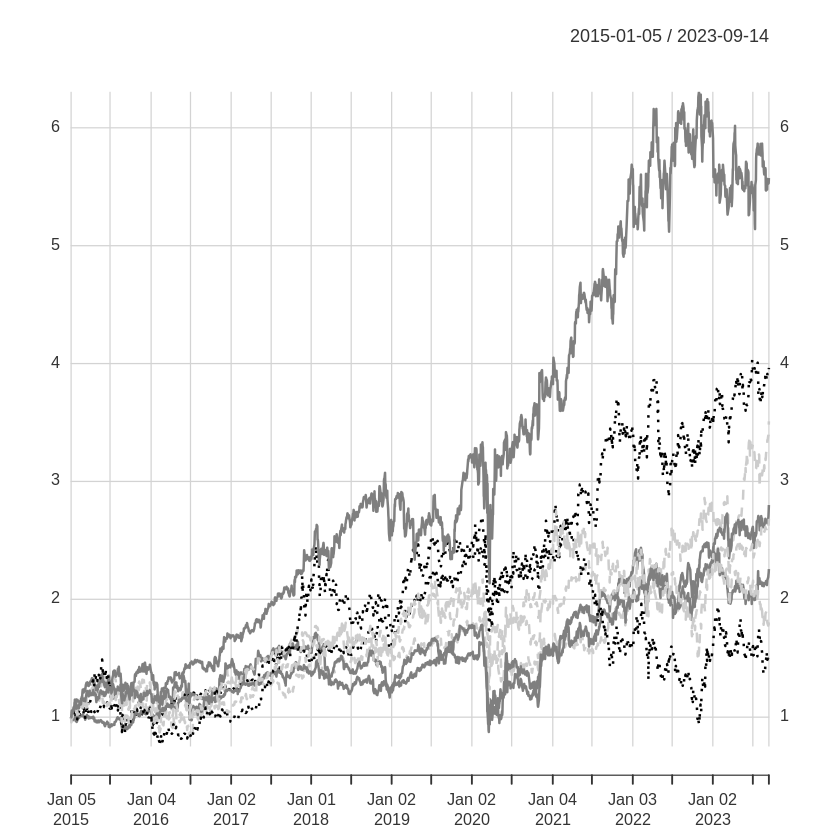

In [ ]:
 mydata <- prices/rep(prices[1, ], each = nrow(prices))
 plot(mydata,   main = "", grid.col = "lightgray",
      col = grey_types, lty = line_types)

In [ ]:
HtmlEval <- TRUE
if (HtmlEval) {
  FigRed    = "red"        ;  FigBlue   = "blue"
  FigGreen  = "green"      ;  FigLBlue  = "lightblue"
  FigDBlue  = "darkblue"   ;  FigDGreen = "darkgreen"
  FigLGreen = "lightgreen" ;  FigOrange = "orange"
  } else {
  FigRed    = "black"      ;  FigBlue   = "black"
  FigGreen  = "black"      ;  FigLBlue  = "gray"
  FigDBlue  = "black"      ;  FigDGreen = "gray"
  FigLGreen = "gray"       ;  FigOrange = "black"
  }


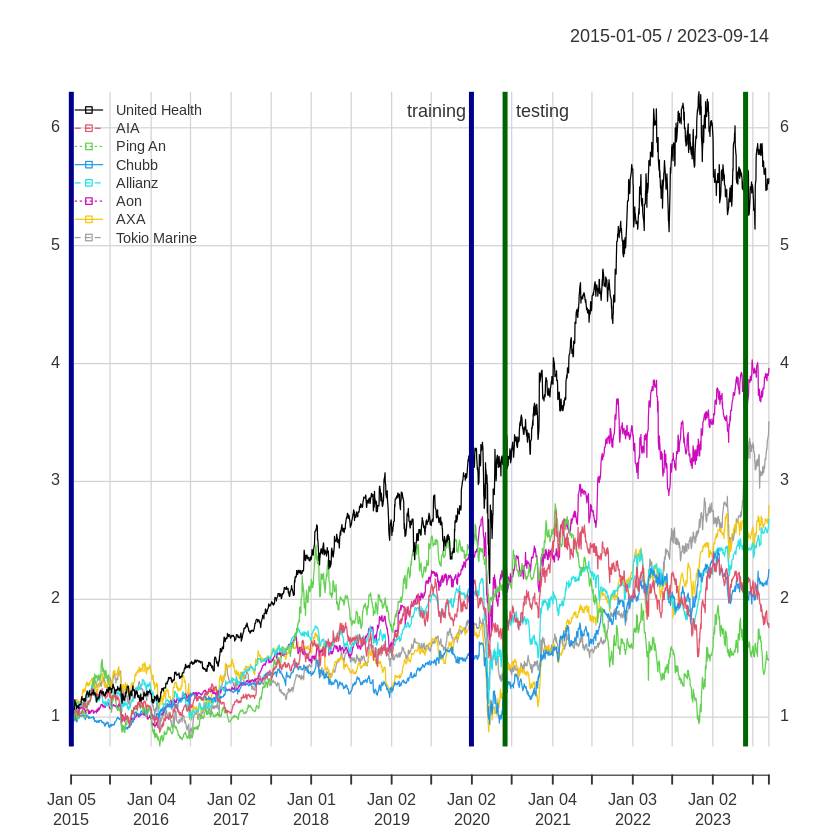

In [ ]:
HtmlEval <- TRUE
#  Plot Figure 1.1
#save(Return, p.num, Return_trn, Return_tst,
#     T_trn, mu, Sigma,
#     file= "../ChapTablesData/Chap1/InsurSectorReturns2023.Rdata")
#load(file= "ChapTablesData/Chap1/InsurSectorPrices2023.Rdata")
#load(file= "ChapTablesData/Chap1/InsurSectorReturns2023.Rdata")


library(RColorBrewer)
line_types <- c("solid", "dashed", "dotted","solid",
                "dashed", "dotted", "solid", "dashed")
grey_types <- c("grey50", "grey80","black", "grey50",
                "grey80","black", "grey50", "grey80")

{ if (HtmlEval) {  plot(mydata,   main = "", grid.col = "lightgray", lwd = 1)} else {
 plot(mydata,   main = "", grid.col = "lightgray", #lwd = 1, #col = "black"
      col = grey_types, lty = line_types) }
addLegend("topleft", pch=0, cex=0.8,lty = line_types)
addEventLines(xts("                      ",
                  index(Return["2015-01-06"])), srt=00,
                        pos=1, lwd = 4, col = FigDBlue)
addEventLines(xts("training              ",
                  index(Return["2019-12-31"])), srt=00,
                        pos=1, lwd = 4, col = FigDBlue)
addEventLines(xts("               testing",
                  index(Return["2020-06-01"])),  srt=0,
                        pos=1, lwd = 4, col = FigDGreen)
addEventLines(xts("",
                  index(Return["2023-05-31"])),  srt=0,
                        pos=1, lwd = 4, col = FigDGreen)
}

This is figure appears in the book (Section 1.3).

In [ ]:
#  Create Table 1.4
temp1 <- t(table.AnnualizedReturns(Return_trn))
temp2 <- t(table.AnnualizedReturns(Return_tst))
RetSumm <- cbind(as.matrix(temp1), as.matrix(temp2))
colnames(RetSumm) <- c("Train Ann Return",    "Train Std Dev",
                       "Train Sharpe (Rf=0)", "Test Ann Return",
                       "Test Std Dev", "Test Sharpe (Rf=0)" )
RetSumm
#TableGen1(TableData=RetSumm,
#         TextTitle='Insurance Sector Performance Measures',
#         Align='r', Digits=3, ColumnSpec=1:6,
#         ColWidth0= "3.5cm", ColumnSpec0 = 1,
#         BorderRight= c(1,4), ColWidth= "1.2cm")


,Train Ann Return,Train Std Dev,Train Sharpe (Rf=0),Test Ann Return,Test Std Dev,Test Sharpe (Rf=0)
United Health,0.2538,0.2127,1.1929,0.2065,0.2202,0.9377
AIA,0.1468,0.2394,0.6133,0.0219,0.3112,0.0705
Ping An,0.1888,0.2643,0.7142,-0.1080,0.3770,-0.2864
Chubb,0.0875,0.1604,0.5458,0.1623,0.2374,0.6837
Allianz,0.1505,0.1932,0.7790,0.0918,0.2280,0.4026
Aon,0.1817,0.1695,1.0721,0.1827,0.2354,0.7763
AXA,0.1155,0.2406,0.4800,0.2113,0.2451,0.8620
Tokio Marine,0.1191,0.2666,0.4468,0.2951,0.2479,1.1903


We can get some quick summaries with the 'table' function in 'R'.

Here is some output that we can get from "Hmisc." This example also illustrates how to create functions in "R".

#  Create Optimal Portfolio

We first need to install a package for convex optimization called CVXR. For doing this on my own machine, it is straightforward - similar to any other package. However, for Colab, we need to grab an older version to make things works. I used Gemini to help me get through this. It is not something that you will need to do on your own system. Sadly, it also takes a while (10 minutes or so). Get it started, and walk away to something else.

For example, read Section 3.4 of the book to get more background on the asset allocation problem.

In [ ]:
system('sudo apt-get update && sudo apt-get install -y libgmp-dev libmpfr-dev')
install.packages("remotes",
  repos = "https://cloud.r-project.org" )

remotes::install_version(package = "CVXR",
  version = "1.0-15",repos = "https://cloud.r-project.org",
  upgrade = "never")
library(CVXR)


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
portolioMinVar <- function(Sigma) {
  c.prop <- Variable(nrow(Sigma))
  prob   <- Problem(Minimize(quad_form(c.prop, Sigma)),
                  constraints = list(c.prop >= 0, sum(c.prop) == 1))
  result <- suppressWarnings(solve(prob))
  c.prop <- as.vector(result$getValue(c.prop))
  names(c.prop) <- colnames(Sigma)
  return(c.prop)
}
portolioMarkowitz <- function(mu, Sigma, lmd = 10) {
  c.prop <- Variable(nrow(Sigma))
  prob   <- Problem(Maximize(t(mu) %*% c.prop -
                    lmd*quad_form(c.prop, Sigma)),
                    constraints = list(c.prop >= 0, sum(c.prop) == 1))
  result <- suppressWarnings(solve(prob))
  c.prop <- as.vector(result$getValue(c.prop))
  names(c.prop) <- colnames(Sigma)
  return(c.prop)
}
c_Markowitz <- portolioMarkowitz(mu, Sigma)
c_MinVar <- portolioMinVar(Sigma)
c_Equal <- rep(1/8,8)
c_all <- cbind("MinVar"      = c_MinVar,
               "Markowitz"   = c_Markowitz,
               "Equal"       = c_Equal)

# compute returns of all portfolios
ret_all     <- xts(Return     %*% c_all, index(Return    ))
ret_all_trn <- xts(Return_trn %*% c_all, index(Return_trn))
ret_all_tst <- xts(Return_tst %*% c_all, index(Return_tst))

temp1 <- t(table.AnnualizedReturns(Return_trn))
temp2 <- t(table.AnnualizedReturns(Return_tst))
RetSumm <- cbind(as.matrix(temp1), as.matrix(temp2))
colnames(RetSumm) <- c("Train Ann Return", "Train Std Dev",
                       "Train Sharpe (Rf=0)", "Test Ann Return",
                       "Test Std Dev", "Test Sharpe (Rf=0)")
Lambda.vec <- c(seq(from=0, to = 3, length.out = 5),
                seq(from=3.5, to = 12, length.out = 5),
                seq(from=12.5, to = 100, length.out = 5))
Portmu     <- rep(0,length(Lambda.vec)) -> Portstd
PortPerf   <- matrix(0,2,length(Lambda.vec))
for (iVec in 1:length(Lambda.vec)) {
   MarkPort        <- portolioMarkowitz(mu, Sigma, lmd = Lambda.vec[iVec])
   ret_MarkPort    <- xts(Return_trn %*% MarkPort, index(Return_trn))
   PortPerf[,iVec] <- t(table.AnnualizedReturns(ret_MarkPort)[1:2,1])
   }
temp1    <- t(table.AnnualizedReturns(ret_all_trn))
temp2    <- t(table.AnnualizedReturns(ret_all_tst))
PortSumm <- cbind(as.matrix(temp1), as.matrix(temp2))
PortSumm

,Annualized Return,Annualized Std Dev,Annualized Sharpe (Rf=0%),Annualized Return,Annualized Std Dev,Annualized Sharpe (Rf=0%)
MinVar,0.1639,0.1190,1.3775,0.1682,0.1428,1.1783
Markowitz,0.2033,0.1260,1.6137,0.1656,0.1428,1.1597
Equal,0.1731,0.1302,1.3295,0.1554,0.1422,1.0928


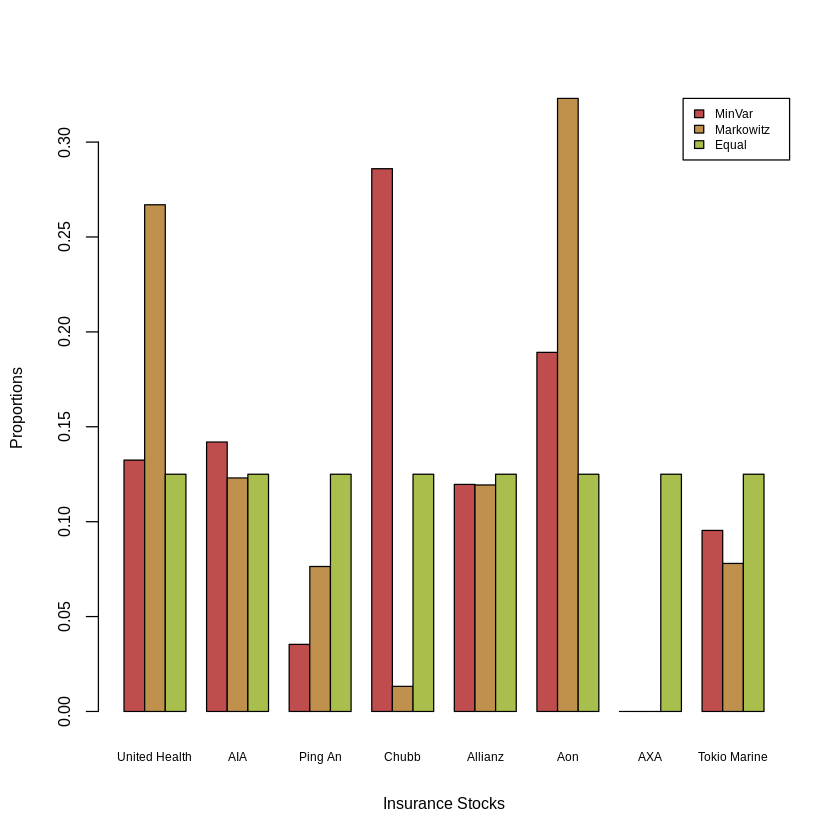

In [ ]:
barplot(t(c_all), col = rainbow10equal[1:3], legend = colnames(c_all),
        cex=0.8, args.legend = list(x = "topright", ncol = 1, cex=0.6),
        cex.names=0.6, beside = TRUE, cex.lab=0.8, main = "",
        xlab = "Insurance Stocks", ylab = "Proportions")

#  Download Your Own Data

Instead of using data I downloaded earlier, you can use the following code to download your own data and then re-run the prior code.

*  See if you can download more recent data.
*  If you have time and interest, try picking a few different investments.

## R Code to Extract Yahoo Returns

In [ ]:
install.packages("quantmod")   # to download stock data
library(quantmod)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
# Example 1.1
# download data from Yahoo Finance
# Pick some insurance stocks...
# https://companiesmarketcap.com/insurance/largest-insurance-companies-by-market-cap/
# https://finance.yahoo.com/

stock_namelist <- c("UNH", "1299.HK","2318.HK",  "CB",
                    "ALV.DE", "AON",  "CS.PA",  "8766.T")
datesToFrom <- c("2015-01-01", "2025-12-31")
prices <- xts()
for (i in 1:length(stock_namelist)) {
  tmp <- Ad(getSymbols(stock_namelist[i], from = datesToFrom[1],
                       to = datesToFrom[2], auto.assign = FALSE))
  tmp <- na.approx(tmp, na.rm = FALSE)  # interpolate NAs
  prices <- cbind(prices, tmp)
  }
for (i in 1:ncol(prices)) {
  prices[,i] <- na.approx(prices[,i], na.rm = FALSE)  # interpolate NAs
  }

Short_stock_namelist <- c("United Health", "AIA","Ping An",  "Chubb",
                          "Allianz", "Aon",  "AXA",  "Tokio Marine")
colnames(prices) <- Short_stock_namelist
indexClass(prices) <- "Date"
prices <- prices[-nrow(prices),]
prices <- prices[-1,]
# I 'save' and 'load' intermediate steps while developing.
# If you are re-running code to check, this is not necessary.

#save(prices, file= "../ChapTablesData/Chap1/InsurSectorPrices2023.Rdata")

Warning message in `indexClass<-`(`*tmp*`, value = "Date"):
“'indexClass<-' is deprecated.
Use 'tclass<-' instead.
See help("Deprecated") and help("xts-deprecated").”


##  R code to split the data into training and test portions

In [ ]:
# Example 1.1,  Create Returns
# save(prices, file= "../ChapTablesData/Chap1/InsurSectorPrices2023.Rdata")
#load(file= "../ChapTablesData/Chap1/InsurSectorPrices2023.Rdata")

Return <- (prices/stats::lag(prices) - 1)[-1]
p.num  <- ncol(Return)  # number of stocks

#We now divide the data into a training set and test set:
# Training 2015-01-05 to 2019-12-31
# TestingOLD 2020-06-01 to 2022-05-31
# Testing 2020-06-01 to 2023-08-31

Return_trn <- Return[1:1299, ]
Return_tst <- Return[1427:2188, ]

T_trn <- nrow(Return_trn)
mu    <- colMeans(Return_trn, na.rm = TRUE)
Sigma <- cov(Return_trn, use = "pairwise.complete.obs")

#save(Return, p.num, Return_trn, Return_tst,
#     T_trn, mu, Sigma,
#     file= "../ChapTablesData/Chap1/InsurSectorReturns2023.Rdata")